<a href="https://colab.research.google.com/github/yusarc/whistled-melody-librosa-analysis/blob/main/whistle_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files

uploaded = files.upload()

Saving whistle_melody.m4a to whistle_melody.m4a


In [4]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

audio_path = "whistle_melody.m4a"

y, sr = librosa.load(audio_path, sr=None)
print(f"Signal shape: {y.shape}, Sample rate: {sr}")


/tmp/ipykernel_622/3156407124.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Signal shape: (819200,), Sample rate: 44100


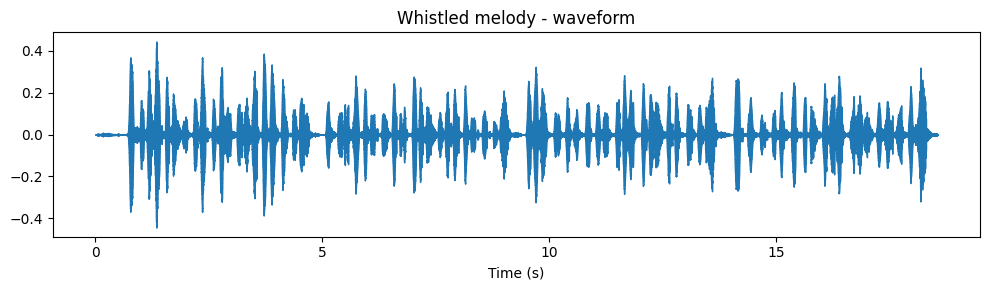

In [5]:
#Waveform

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Whistled melody - waveform")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()


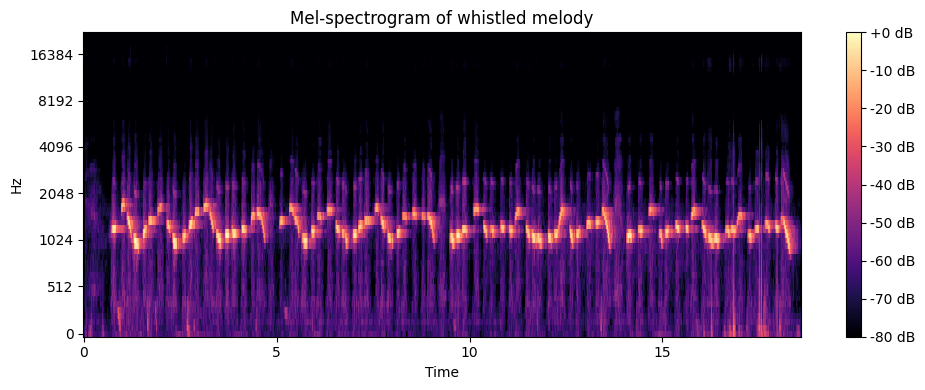

In [6]:
# Mel-spektogram

S = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=2048,
    hop_length=512,
    n_mels=64
)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel-spectrogram of whistled melody")
plt.tight_layout()
plt.show()


Estimated tempo: 83.35 BPM


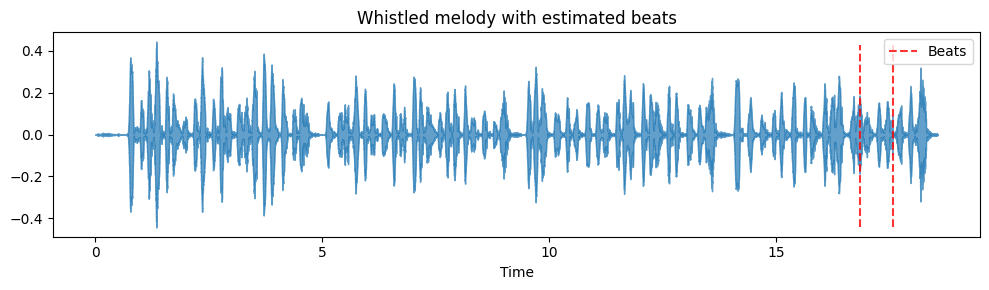

In [8]:
# Tempo and Beats
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)

if isinstance(tempo, np.ndarray):
    tempo_value = tempo[0]
else:
    tempo_value = tempo

print(f"Estimated tempo: {tempo_value:.2f} BPM")

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr, alpha=0.7)
times = librosa.frames_to_time(beat_frames, sr=sr)
plt.vlines(
    times,
    ymin=y.min(),
    ymax=y.max(),
    color="r",
    alpha=0.8,
    linestyle="--",
    label="Beats"
)
plt.legend()
plt.title("Whistled melody with estimated beats")
plt.tight_layout()
plt.show()



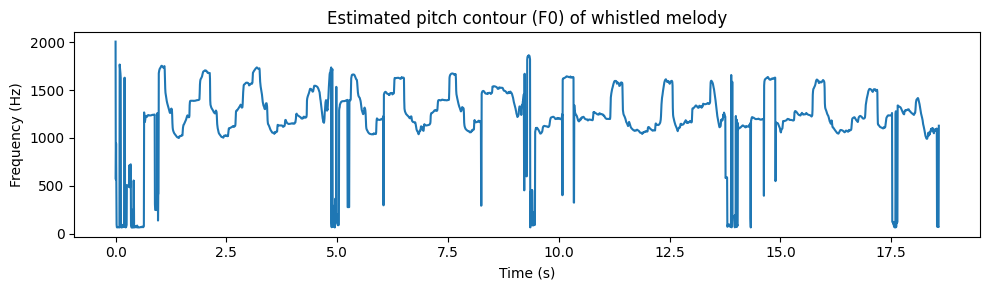

In [9]:
# Pitch Contour(FO)

frame_length = 2048
hop_length = 256

f0 = librosa.yin(
    y,
    fmin=librosa.note_to_hz("C2"),
    fmax=librosa.note_to_hz("C7"),
    sr=sr,
    frame_length=frame_length,
    hop_length=hop_length,
)

times = librosa.times_like(f0, sr=sr, hop_length=hop_length)

plt.figure(figsize=(10, 3))
plt.plot(times, f0)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Estimated pitch contour (F0) of whistled melody")
plt.tight_layout()
plt.show()


In [10]:
# FO

import collections

valid_idx = f0 > 0
f0_valid = f0[valid_idx]

notes = librosa.hz_to_note(f0_valid)

note_counts = collections.Counter(notes)
note_counts.most_common(10)


[(np.str_('D6'), 494),
 (np.str_('D♯6'), 463),
 (np.str_('C♯6'), 427),
 (np.str_('C6'), 280),
 (np.str_('E6'), 270),
 (np.str_('F♯6'), 244),
 (np.str_('G6'), 241),
 (np.str_('G♯6'), 221),
 (np.str_('F6'), 211),
 (np.str_('A6'), 46)]